# WIA1006 Machine Learning: Predicting Crop Production in Malaysia

In this project, we aim to train, optimize and compare several machine learning models and compare their performance in solving real-world problems.


### Step 1: Import Necessary Libraries

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score


### Step 2: Perform Training in 5 different models

In this project, we used 5 models:
- Linear Regression
- Random Forest
- XGBoost
- SVR
- MLP Regressor


In [ ]:
# 1. Load data
df = pd.read_csv("processed_data.csv")

# 2. Encode categorical features
le_state = LabelEncoder()
df['state'] = le_state.fit_transform(df['state'])
# One Hot Encoding for crop type
df = pd.get_dummies(df, columns=['crop_type'], drop_first=True)

# 3. Train-Test split by year
train_df = df[df['year'] < 2022]
test_df = df[df['year'] == 2022]

# 4. Select features and target
features = [col for col in df.columns if col not in ['year', 'production']]
X_train, y_train = train_df[features], train_df['production']
X_test, y_test = test_df[features], test_df['production']

# 5. Normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "SVR": SVR(),
    "MLP Regressor": MLPRegressor(random_state=42, max_iter=1000)
}

# 7. Train and Evaluate
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    results.append((name, mae, r2))

# 8. Show results
results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'R2 Score'])
print(results_df.sort_values(by='MAE'))


               Model           MAE  R2 Score
2            XGBoost  3.012842e+05  0.998161
1      Random Forest  1.529485e+06  0.933688
3                SVR  5.027521e+06 -0.022156
4      MLP Regressor  5.028392e+06 -0.021978
0  Linear Regression  2.008668e+07 -0.172210


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


We can categorize the results in two categories:


Category 1 : Model with acceptable performance

---

*   XGBoost (R2 Score = 0.998)
*   Random Forest (R2 Score = 0.934)

Category 2 : Model with worse performance

---

*   SVR (R2 Score = -0.022)
*   MLP Regressor (R2 Score = -0.022)
*   Linear Regression (R2 Score = -0.172)



**Inference**

The R2 score of SVR, MLP Regressor and Linear Regression is less than 0, which indicates that the model performs worse than just random guessing mean value. This shows that the model is fundamentally broken or misconfigured.

From the performance above, we can infer that the features in the provided dataset doesn't show a linear relationship. **Tree-based models** (Random Forest, XGBoost) handle non-linear patterns and feature interactions natively while **linear regression** assumes a straight-line relationship between inputs and output (which is too simplistic here).

Besides that, the extreme outlier in the production of `crop_type` "flower" have a massive production values compare to others. This overwhelmed the whole linear regression model but tree-based model are more resilient to skewed target distributions / extreme values, hence it is not affected much.



## Step 3: Optimising - Linear Regression

**Problem statement:** If the outlier in `crop_type:flower` greatly affects the performace, can we remove the data / train the model separately to optimise the performance of the linear regression model?


Attempt 1: Remove the rows with `crop_type:flower` and train the linear regression model again.

In [ ]:
# 1. Load data
df = pd.read_csv("processed_data.csv")

# 2. Encode categorical features
le_state = LabelEncoder()
df['state'] = le_state.fit_transform(df['state'])
df = df[df['crop_type'] != 'flower'].copy()
# One Hot Encoding for crop type
df = pd.get_dummies(df, columns=['crop_type'], drop_first=True)

# 3. Train-Test split by year
train_df = df[df['year'] < 2022]
test_df = df[df['year'] == 2022]

# 4. Select features and target
features = [col for col in df.columns if col not in ['year', 'production']]
X_train, y_train = train_df[features], train_df['production']
X_test, y_test = test_df[features], test_df['production']

# 5. Normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "SVR": SVR(),
    "MLP Regressor": MLPRegressor(random_state=42, max_iter=1000)
}

# 7. Train and Evaluate
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    results.append((name, mae, r2))

# 8. Show results
results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'R2 Score'])
print(results_df.sort_values(by='MAE'))


               Model            MAE  R2 Score
1      Random Forest   17833.503141  0.976425
2            XGBoost   19119.828810  0.960375
0  Linear Regression   70883.219950  0.814097
4      MLP Regressor  103233.166856 -0.046964
3                SVR  104702.997708 -0.099906


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


From the model performance above, after removing the extreme outliers in the production of `crop_type:flower`, the performance of the Linear Regression model increase drastically from -0.172 to 0.814. Although one hot encoding is used in training the linear regression at first, separating / removing the `crop_type:flower` give the model better performance.

However, it is still not completed yet as we are missing the model for `crop_type:flower`. How about we train all the different crop type separately?

**Attempt 2**: Separate the dataset according to their respective `crop_type` and train them accordingly.




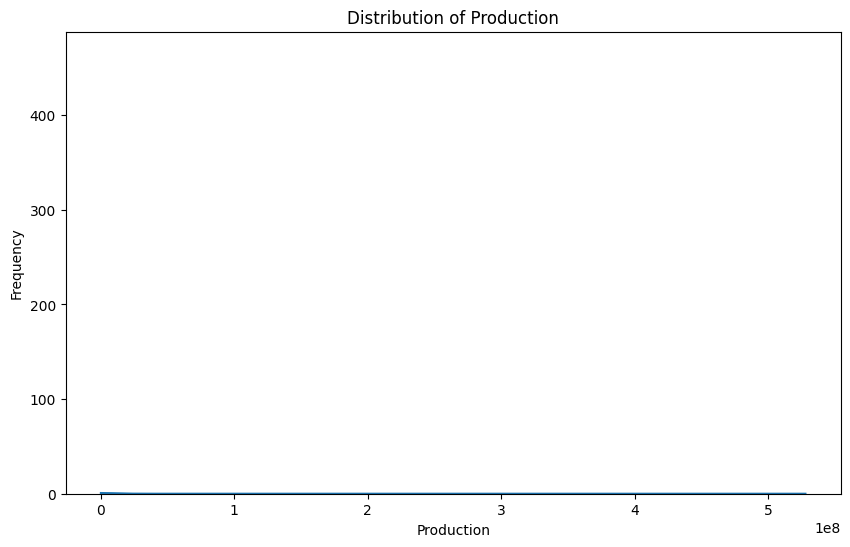

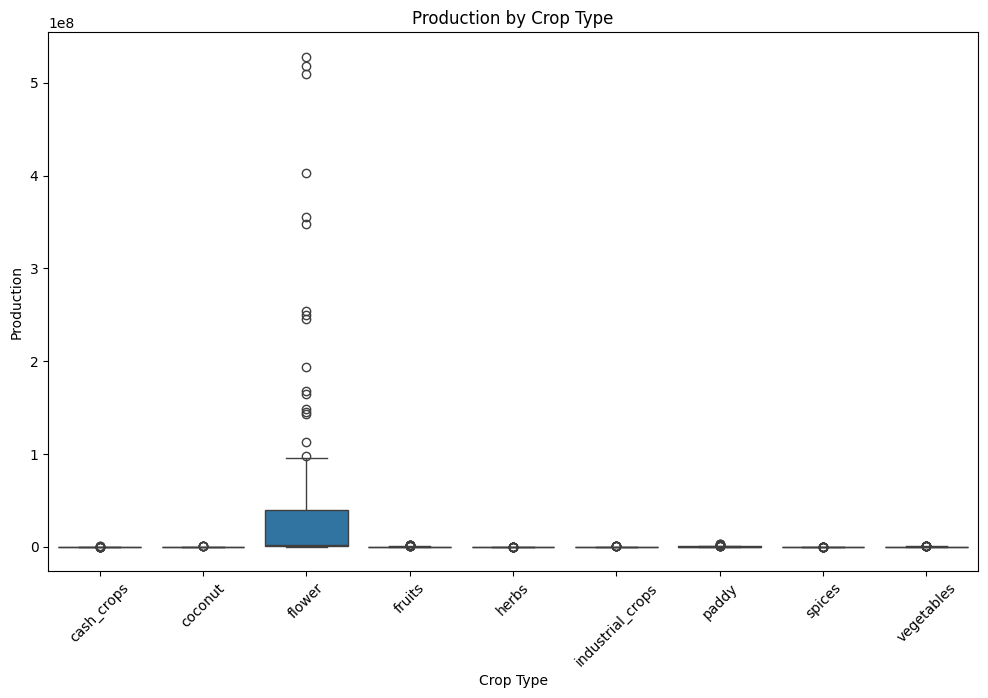


Number of outliers in 'production' based on IQR: 130
Outliers in 'production':
     year     state  temperature_mean  temperature_max  temperature_min  \
2    2017     Johor         28.282802        38.752941        22.000000   
3    2017     Johor         28.282802        38.752941        22.000000   
11   2017     Kedah         28.269035        38.544000        22.000000   
15   2017     Kedah         28.269035        38.544000        22.000000   
20   2017  Kelantan         28.248498        38.737255        22.388889   
..    ...       ...               ...              ...              ...   
857  2022  Malaysia         27.274096        41.900000         0.900000   
858  2022  Malaysia         27.274096        41.900000         0.900000   
860  2022  Malaysia         27.274096        41.900000         0.900000   
861  2022  Malaysia         27.274096        41.900000         0.900000   
863  2022  Malaysia         27.274096        41.900000         0.900000   

     temperature_st

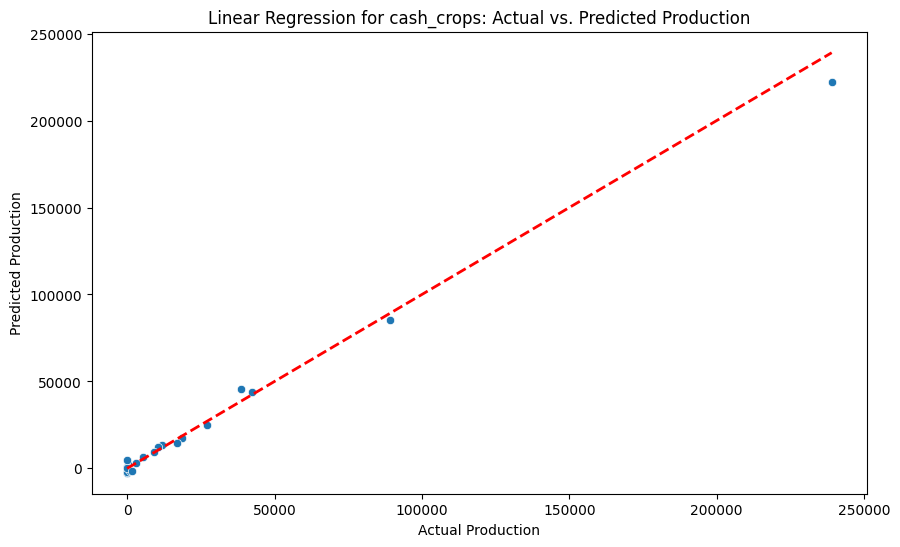

--- Training model for Crop Type: coconut ---
  Mean Squared Error (MSE): 69598004.35
  Root Mean Squared Error (RMSE): 8342.54
  R-squared (R2): 1.00


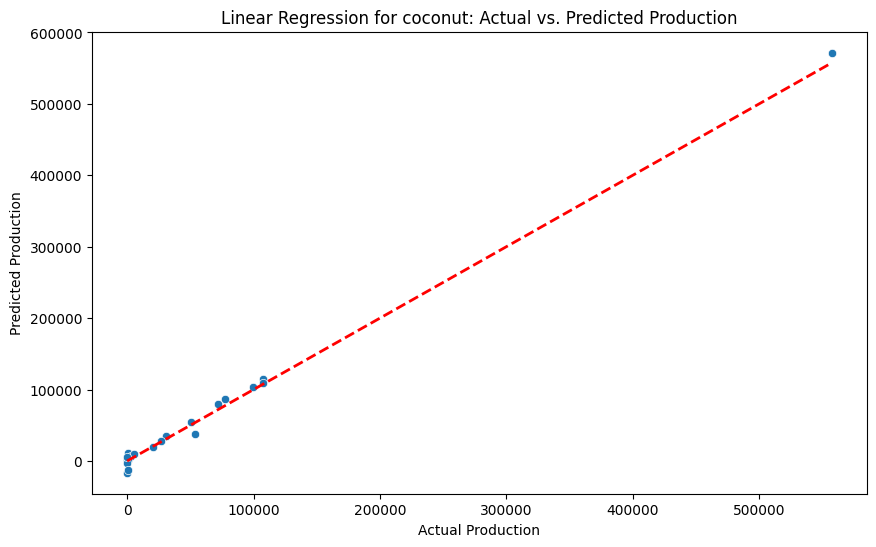

--- Training model for Crop Type: flower ---
  Mean Squared Error (MSE): 339376902026762.56
  Root Mean Squared Error (RMSE): 18422185.05
  R-squared (R2): 0.97


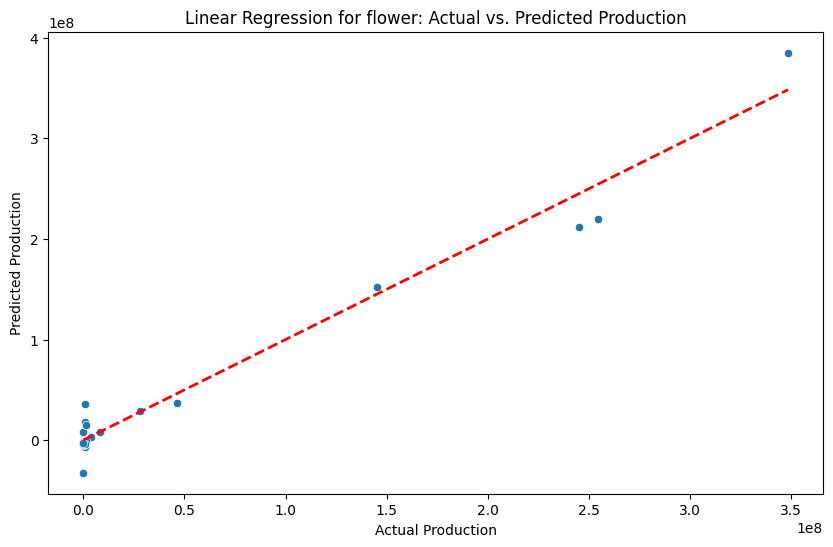

--- Training model for Crop Type: fruits ---
  Mean Squared Error (MSE): 926985951.68
  Root Mean Squared Error (RMSE): 30446.44
  R-squared (R2): 0.99


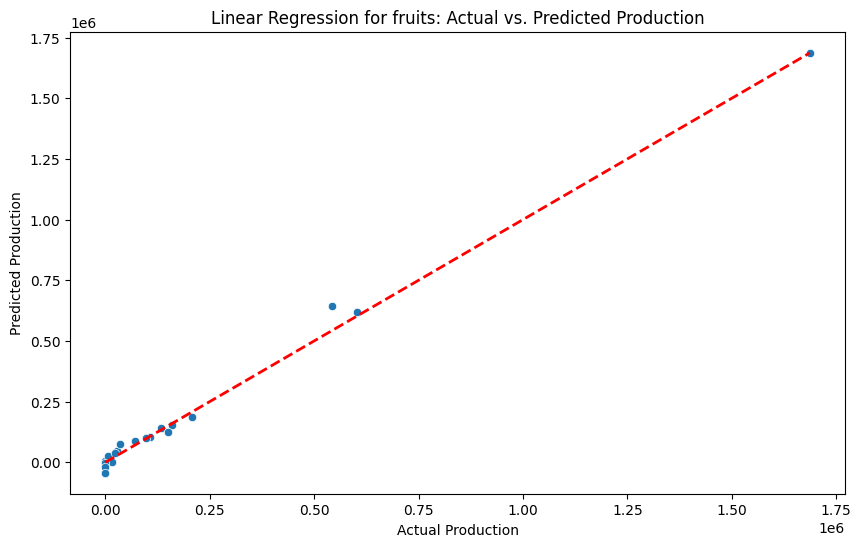

--- Training model for Crop Type: herbs ---
  Mean Squared Error (MSE): 200016.17
  Root Mean Squared Error (RMSE): 447.23
  R-squared (R2): 0.96


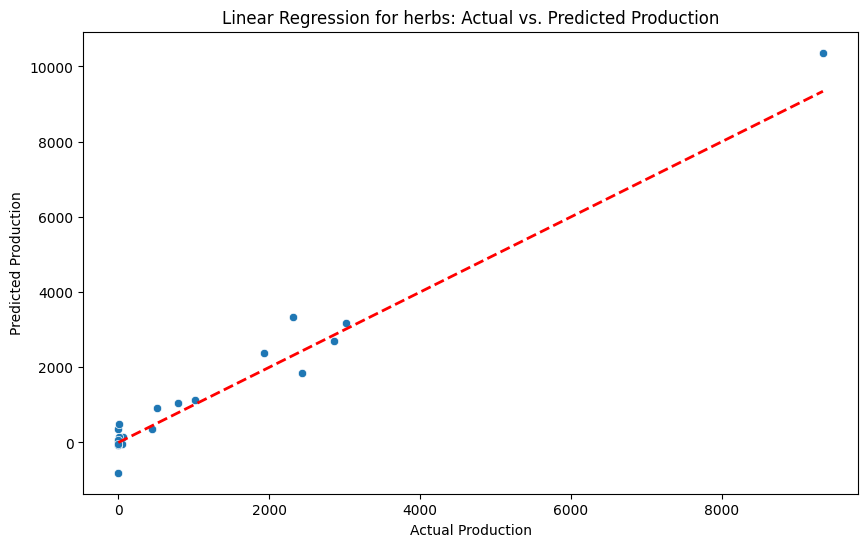

--- Training model for Crop Type: industrial_crops ---
  Mean Squared Error (MSE): 935662958.92
  Root Mean Squared Error (RMSE): 30588.61
  R-squared (R2): 0.96


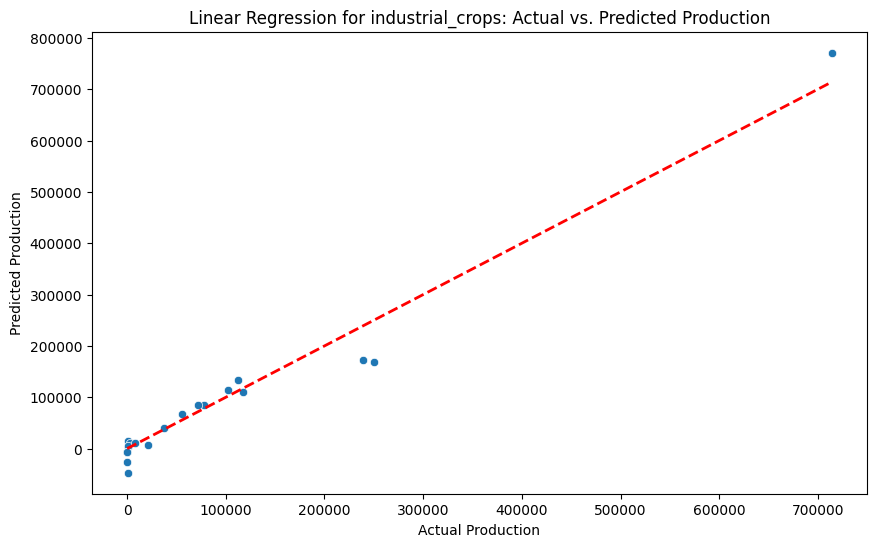

--- Training model for Crop Type: paddy ---
  Mean Squared Error (MSE): 587262015.39
  Root Mean Squared Error (RMSE): 24233.49
  R-squared (R2): 1.00


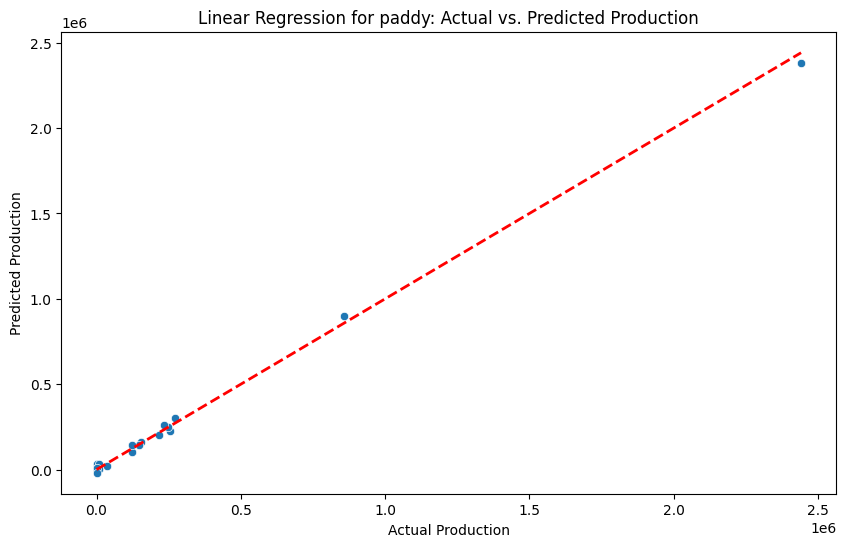

--- Training model for Crop Type: spices ---
  Mean Squared Error (MSE): 708771.17
  Root Mean Squared Error (RMSE): 841.89
  R-squared (R2): 1.00


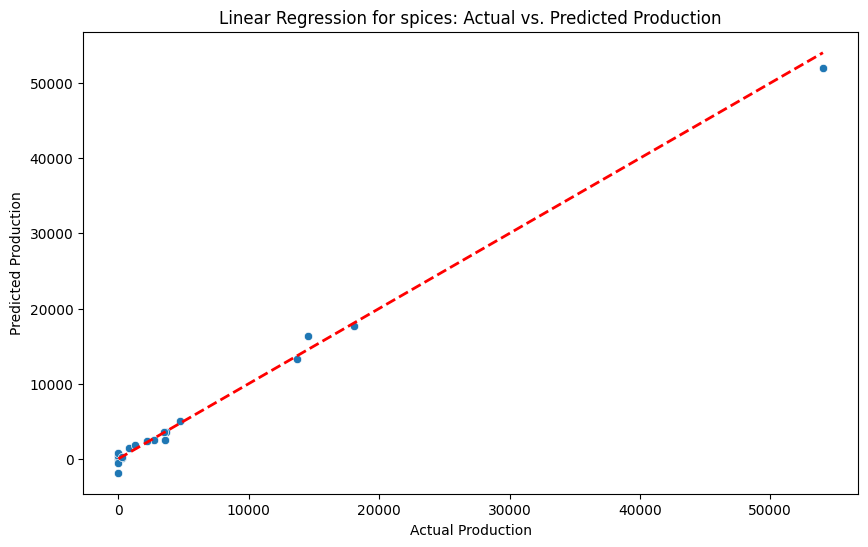

--- Training model for Crop Type: vegetables ---
  Mean Squared Error (MSE): 87892376.05
  Root Mean Squared Error (RMSE): 9375.09
  R-squared (R2): 1.00


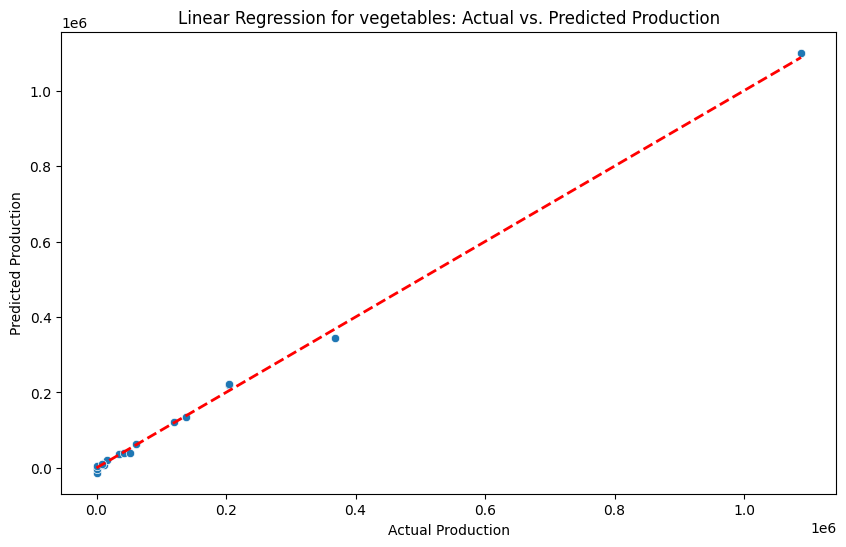


--- Summary of Model Performance by Crop Type ---
Crop Type: cash_crops
  R-squared (R2): 0.99
  RMSE: 4609.08
------------------------------
Crop Type: coconut
  R-squared (R2): 1.00
  RMSE: 8342.54
------------------------------
Crop Type: flower
  R-squared (R2): 0.97
  RMSE: 18422185.05
------------------------------
Crop Type: fruits
  R-squared (R2): 0.99
  RMSE: 30446.44
------------------------------
Crop Type: herbs
  R-squared (R2): 0.96
  RMSE: 447.23
------------------------------
Crop Type: industrial_crops
  R-squared (R2): 0.96
  RMSE: 30588.61
------------------------------
Crop Type: paddy
  R-squared (R2): 1.00
  RMSE: 24233.49
------------------------------
Crop Type: spices
  R-squared (R2): 1.00
  RMSE: 841.89
------------------------------
Crop Type: vegetables
  R-squared (R2): 1.00
  RMSE: 9375.09
------------------------------


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset
df = pd.read_csv('processed_data.csv')

# Identify numerical columns for correlation and distribution analysis
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude 'production' from features for initial correlation
features_for_corr = [col for col in numerical_cols if col != 'production']

# Visualize the distribution of 'production' to identify outliers
plt.figure(figsize=(10, 6))
sns.histplot(df['production'], kde=True)
plt.title('Distribution of Production')
plt.xlabel('Production')
plt.ylabel('Frequency')
plt.show()

# Visualize production by crop type
plt.figure(figsize=(12, 7))
sns.boxplot(x='crop_type', y='production', data=df)
plt.title('Production by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Production')
plt.xticks(rotation=45)
plt.show()

# Outlier detection using IQR method for 'production'
Q1 = df['production'].quantile(0.25)
Q3 = df['production'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_production = df[(df['production'] < lower_bound) | (df['production'] > upper_bound)]
print(f"\nNumber of outliers in 'production' based on IQR: {len(outliers_production)}")
print("Outliers in 'production':")
print(outliers_production)

# Separate features (X) and target (y)
X = df.drop('production', axis=1)
y = df['production']

# Identify categorical and numerical columns
categorical_features = ['state', 'crop_type']
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Get unique crop types
unique_crop_types = df['crop_type'].unique()
print(f"\nUnique Crop Types: {unique_crop_types}\n")

# Dictionary to store models and their performance
models_by_crop_type = {}

for crop_type in unique_crop_types:
    print(f"--- Training model for Crop Type: {crop_type} ---")

    # Filter data for the current crop type
    df_crop = df[df['crop_type'] == crop_type].copy()

    # Separate features (X) and target (y)
    X_crop = df_crop.drop(['production', 'crop_type'], axis=1) # Drop crop_type as it's constant for this subset
    y_crop = df_crop['production']

    # Identify categorical and numerical columns for this subset
    # 'state' is the only remaining categorical feature to encode
    categorical_features_crop = ['state']
    numerical_features_crop = X_crop.select_dtypes(include=np.number).columns.tolist()

    if len(X_crop) == 0:
        print(f"No data for crop type: {crop_type}. Skipping.")
        continue

    # Handle cases where there might not be enough samples for train_test_split (e.g., if a crop type has very few entries)
    if len(X_crop) < 2: # Need at least 2 samples to split into train and test
        print(f"Not enough data for crop type: {crop_type} to split into train/test sets. Skipping model training for this crop type.")
        # Alternatively, you could train on all available data if splitting is not feasible
        continue

    # Create a preprocessor for the current crop type
    # Only scale numerical features and one-hot encode 'state'
    preprocessor_crop = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features_crop),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_crop)
        ],
        remainder='passthrough'
    )

    # Create a pipeline with preprocessing and Linear Regression
    model = Pipeline(steps=[('preprocessor', preprocessor_crop),
                            ('regressor', LinearRegression())])

    # Split the data into training and testing sets
    X_train_crop, X_test_crop, y_train_crop, y_test_crop = train_test_split(X_crop, y_crop, test_size=0.2, random_state=42)

    # Train the model
    model.fit(X_train_crop, y_train_crop)

    # Make predictions
    y_pred_crop = model.predict(X_test_crop)

    # Evaluate the model
    mse_crop = mean_squared_error(y_test_crop, y_pred_crop)
    rmse_crop = np.sqrt(mse_crop)
    r2_crop = r2_score(y_test_crop, y_pred_crop)

    print(f"  Mean Squared Error (MSE): {mse_crop:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse_crop:.2f}")
    print(f"  R-squared (R2): {r2_crop:.2f}")

    # Store the model and its performance
    models_by_crop_type[crop_type] = {
        'model': model,
        'mse': mse_crop,
        'rmse': rmse_crop,
        'r2': r2_crop
    }

    # Visualize predictions vs actual values for each crop type
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test_crop, y=y_pred_crop)
    plt.plot([y_test_crop.min(), y_test_crop.max()], [y_test_crop.min(), y_test_crop.max()], 'r--', lw=2)
    plt.xlabel('Actual Production')
    plt.ylabel('Predicted Production')
    plt.title(f'Linear Regression for {crop_type}: Actual vs. Predicted Production')
    plt.show()

print("\n--- Summary of Model Performance by Crop Type ---")
for crop_type, metrics in models_by_crop_type.items():
    print(f"Crop Type: {crop_type}")
    print(f"  R-squared (R2): {metrics['r2']:.2f}")
    print(f"  RMSE: {metrics['rmse']:.2f}")
    print("-" * 30)

The R2 value of each linear regression model performs considerably well (>0.95) after we separately train the data based on their respective `crop_type`. Hence the optimal way is to train the data based on their category if a linear regression model is used.

## Step 4: Optimising - SVR

Optimising an SVR model can be done through several ways. (✅ indicates has been done in previous attempts)

1. Use StandardScaler to properly preprocess the data. ✅
2. Log-transforming the target value (production).
3. Filtering or grouping outlier `crop_types` separately to train specialised models.

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV


param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}

y_train_log = np.log1p(y_train)

grid = GridSearchCV(SVR(), param_grid, cv=3, scoring='r2')
grid.fit(X_train_scaled, y_train_log)

print("Best Params:", grid.best_params_)
best_svr = grid.best_estimator_

# Predict and evaluate
y_pred = best_svr.predict(X_test_scaled)


Best Params: {'C': 10, 'epsilon': 1, 'kernel': 'rbf'}


R² Score: 0.0936
RMSE: 1028586011035069.75
MAE: 4836060.05


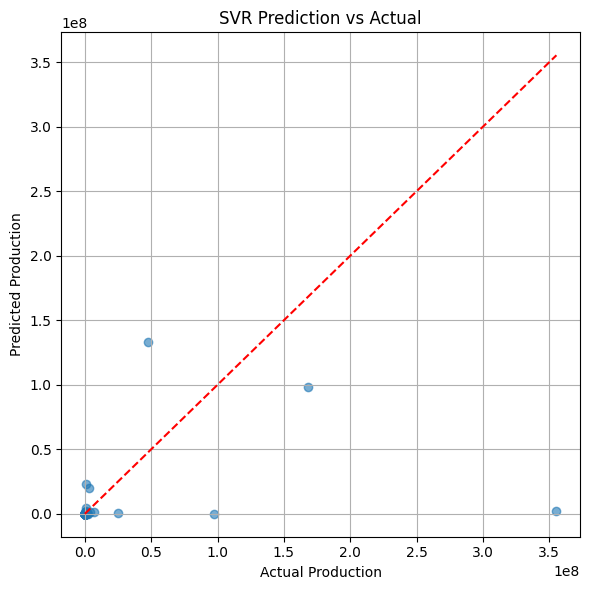

In [ ]:
# From the above evaluation, we know that the best params is {'C': 10, 'epsilon': 1, 'kernel': 'rbf'}
svr_best = SVR(C=10, epsilon=1, kernel='rbf')
svr_best.fit(X_train_scaled, y_train_log)

y_pred = svr_best.predict(X_test_scaled)

y_pred = np.expm1(y_pred)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("SVR Prediction vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

After optimising, unfortunately the model still doesn't perform quite well, with a R2 score of only 0.094.

In conclusion, an XGBoost or Random Forest is more preferred, following by the linear regression model in training this dataset as a lot of the data are not correlated linearly, and extreme outliers based on different group exists.

--- Training model for Crop Type: cash_crops ---
  Mean Squared Error (MSE): 3214220895.41
  Root Mean Squared Error (RMSE): 56694.10
  R-squared (R2): -0.13


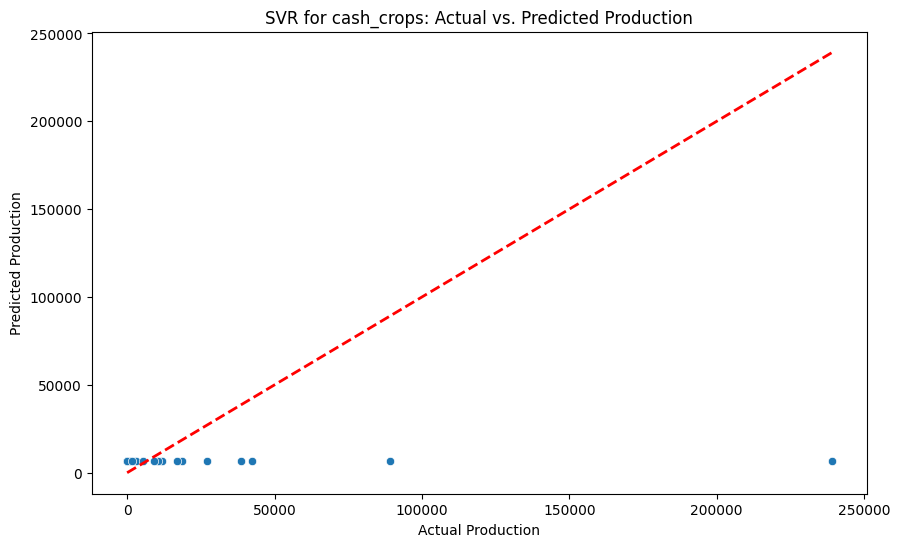

--- Training model for Crop Type: coconut ---
  Mean Squared Error (MSE): 15768442053.66
  Root Mean Squared Error (RMSE): 125572.46
  R-squared (R2): -0.09


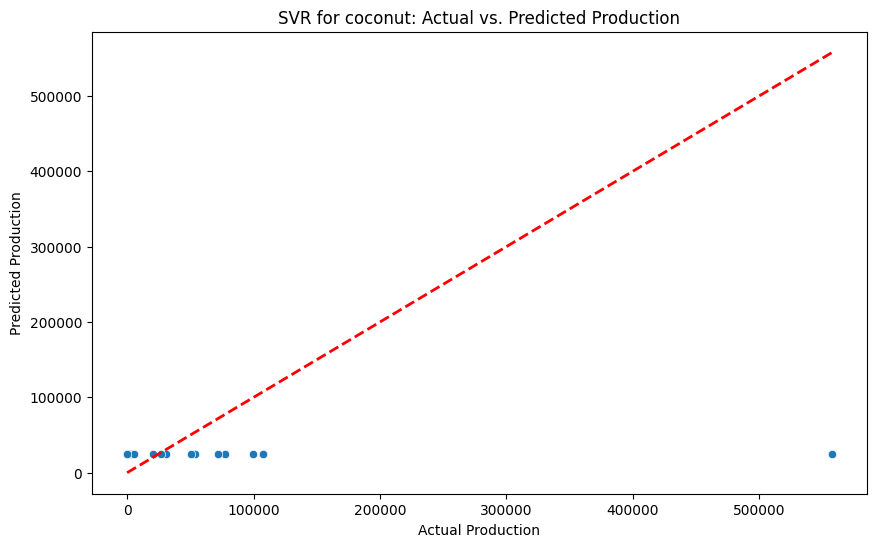

--- Training model for Crop Type: flower ---
  Mean Squared Error (MSE): 13212737450772392.00
  Root Mean Squared Error (RMSE): 114946672.20
  R-squared (R2): -0.25


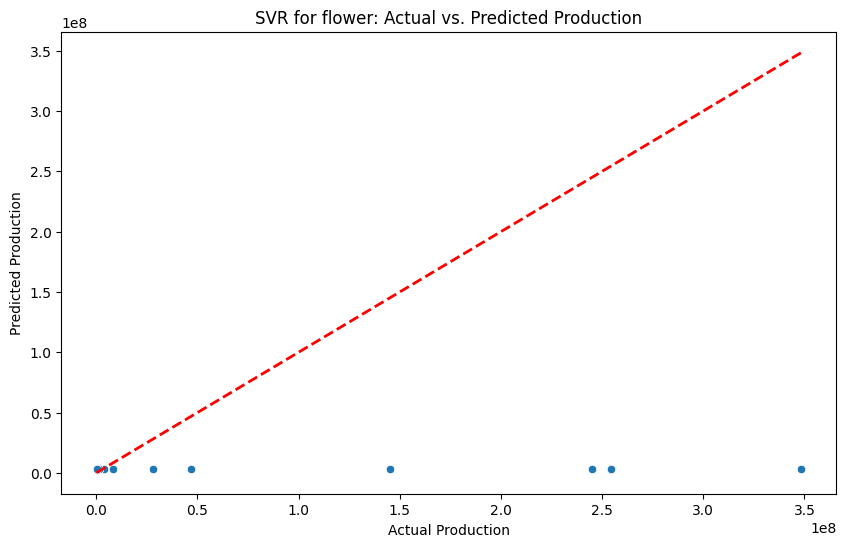

--- Training model for Crop Type: fruits ---
  Mean Squared Error (MSE): 160651172883.78
  Root Mean Squared Error (RMSE): 400813.14
  R-squared (R2): -0.11


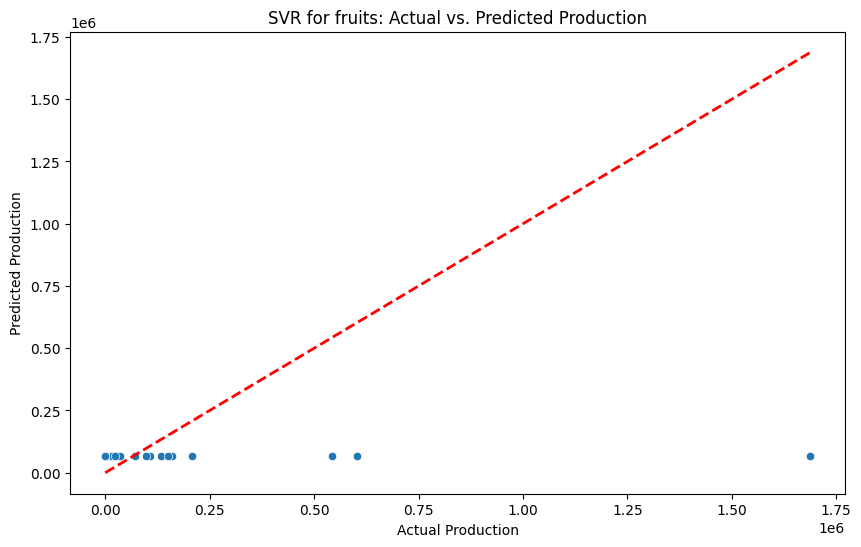

--- Training model for Crop Type: herbs ---
  Mean Squared Error (MSE): 5337248.74
  Root Mean Squared Error (RMSE): 2310.25
  R-squared (R2): -0.17


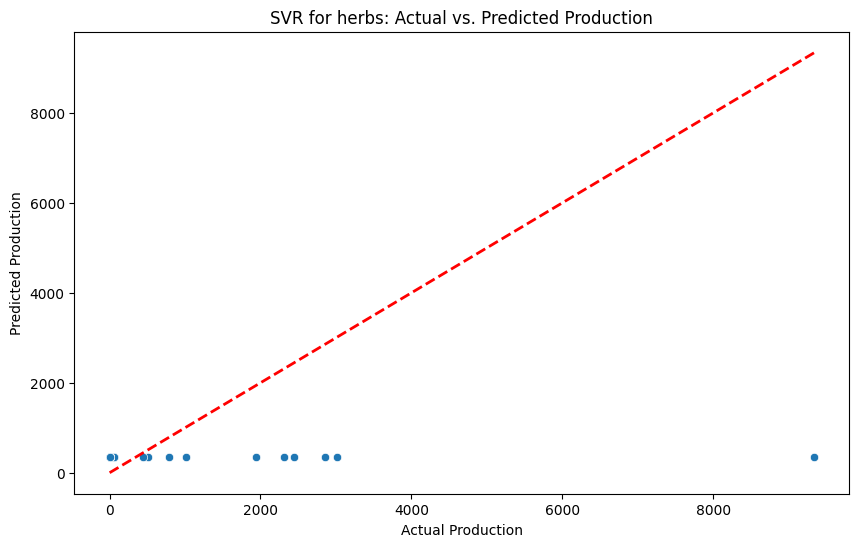

--- Training model for Crop Type: industrial_crops ---
  Mean Squared Error (MSE): 29308550005.14
  Root Mean Squared Error (RMSE): 171197.40
  R-squared (R2): -0.13


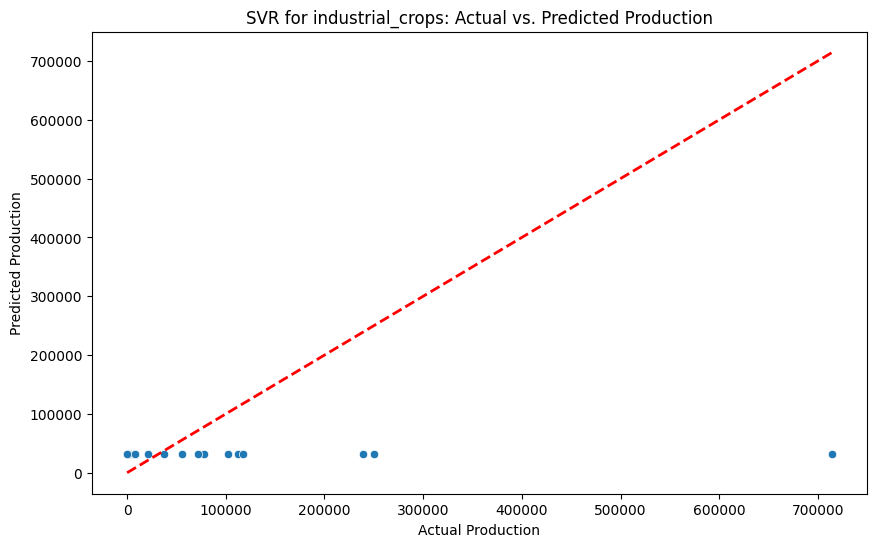

--- Training model for Crop Type: paddy ---
  Mean Squared Error (MSE): 306765995727.48
  Root Mean Squared Error (RMSE): 553864.60
  R-squared (R2): -0.07


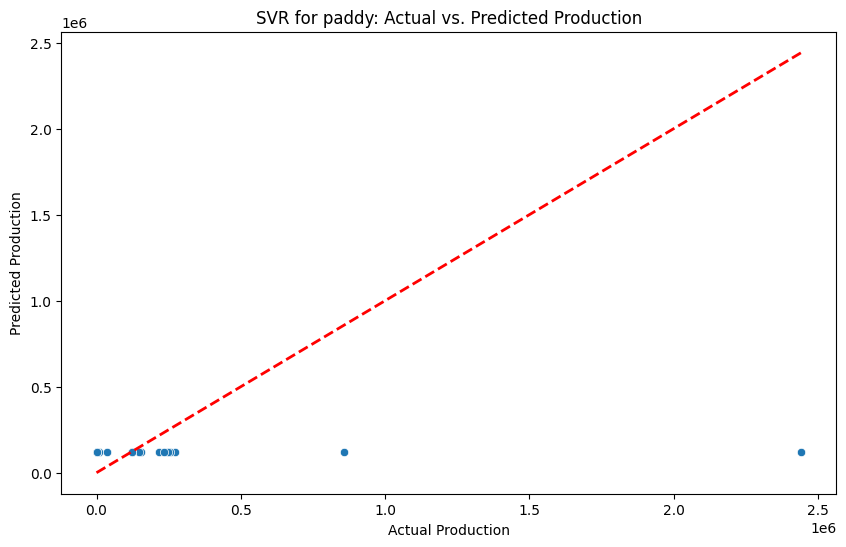

--- Training model for Crop Type: spices ---
  Mean Squared Error (MSE): 159746393.19
  Root Mean Squared Error (RMSE): 12639.08
  R-squared (R2): -0.08


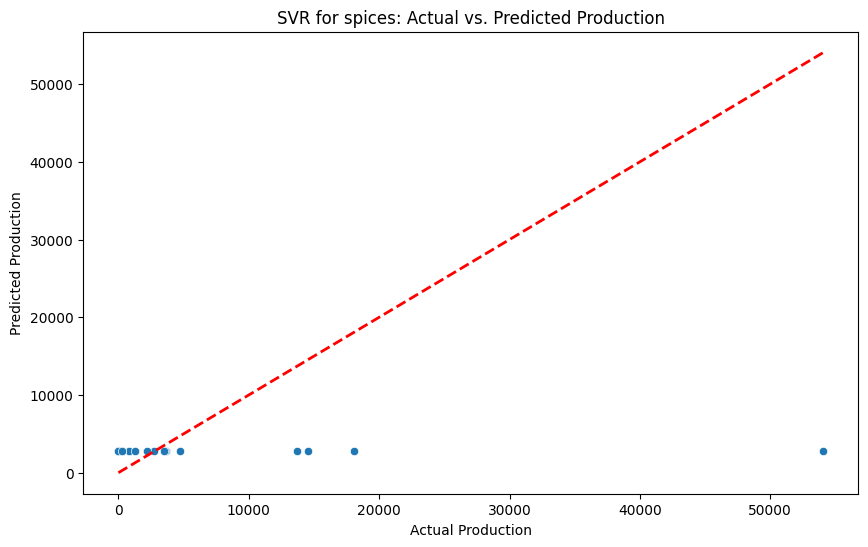

--- Training model for Crop Type: vegetables ---
  Mean Squared Error (MSE): 66460095752.19
  Root Mean Squared Error (RMSE): 257798.56
  R-squared (R2): -0.14


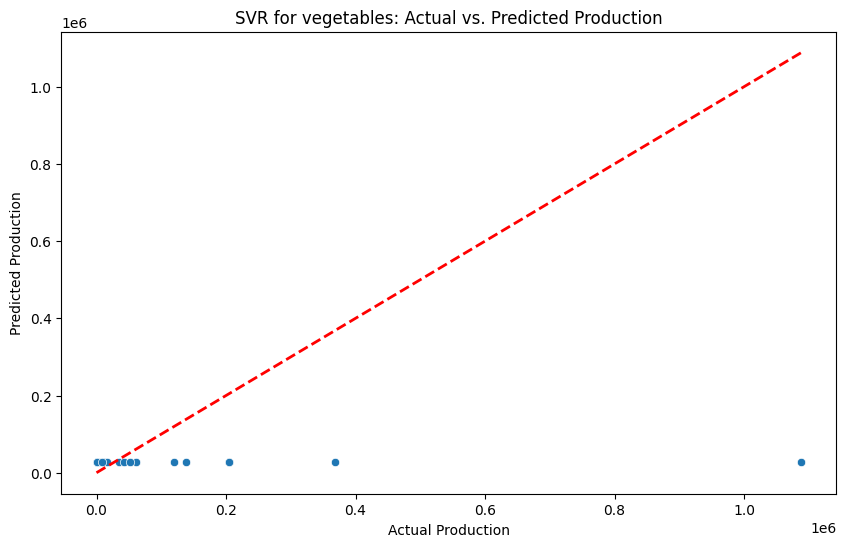

In [ ]:
for crop_type in unique_crop_types:
    print(f"--- Training model for Crop Type: {crop_type} ---")

    # Filter data for the current crop type
    df_crop = df[df['crop_type'] == crop_type].copy()

    # Separate features (X) and target (y)
    X_crop = df_crop.drop(['production', 'crop_type'], axis=1) # Drop crop_type as it's constant for this subset
    y_crop = df_crop['production']

    # Identify categorical and numerical columns for this subset
    # 'state' is the only remaining categorical feature to encode
    categorical_features_crop = ['state']
    numerical_features_crop = X_crop.select_dtypes(include=np.number).columns.tolist()

    if len(X_crop) == 0:
        print(f"No data for crop type: {crop_type}. Skipping.")
        continue

    # Handle cases where there might not be enough samples for train_test_split (e.g., if a crop type has very few entries)
    if len(X_crop) < 2: # Need at least 2 samples to split into train and test
        print(f"Not enough data for crop type: {crop_type} to split into train/test sets. Skipping model training for this crop type.")
        # Alternatively, you could train on all available data if splitting is not feasible
        continue

    # Create a preprocessor for the current crop type
    # Only scale numerical features and one-hot encode 'state'
    preprocessor_crop = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features_crop),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_crop)
        ],
        remainder='passthrough'
    )

    # Create a pipeline with preprocessing and Linear Regression
    model = Pipeline(steps=[('preprocessor', preprocessor_crop),
                            ('regressor', SVR())])

    # Split the data into training and testing sets
    X_train_crop, X_test_crop, y_train_crop, y_test_crop = train_test_split(X_crop, y_crop, test_size=0.2, random_state=42)

    # Train the model
    model.fit(X_train_crop, y_train_crop)

    # Make predictions
    y_pred_crop = model.predict(X_test_crop)

    # Evaluate the model
    mse_crop = mean_squared_error(y_test_crop, y_pred_crop)
    rmse_crop = np.sqrt(mse_crop)
    r2_crop = r2_score(y_test_crop, y_pred_crop)

    print(f"  Mean Squared Error (MSE): {mse_crop:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse_crop:.2f}")
    print(f"  R-squared (R2): {r2_crop:.2f}")

    # Store the model and its performance
    models_by_crop_type[crop_type] = {
        'model': model,
        'mse': mse_crop,
        'rmse': rmse_crop,
        'r2': r2_crop
    }

    # Visualize predictions vs actual values for each crop type
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test_crop, y=y_pred_crop)
    plt.plot([y_test_crop.min(), y_test_crop.max()], [y_test_crop.min(), y_test_crop.max()], 'r--', lw=2)
    plt.xlabel('Actual Production')
    plt.ylabel('Predicted Production')
    plt.title(f'SVR for {crop_type}: Actual vs. Predicted Production')
    plt.show()
